# TP Meilleur algorithme en pratique

On a étudier les algorithmes de tri au niveau théorique. Pour les algorithmes qui se basent sur la comparaison de valeurs, on connait une borne inférieure $\Omega(n \lg n)$ dans le pire des cas. On sait que le tri fusion est en ${\cal O}(n \lg n)$ dans le pire des cas, donc du point de vue de la théorie, on souhaitera utiliser des algorithmes en ${\cal O}(n \lg n)$. Il n'empêche que `quicksort`, même s'il est ${\cal O}(n^2)$ dans le pire des cas, est en ${\cal O}(n \lg n)$ la plupart du temps et a été utilisé en pratique.

Dans ce TP, on veut chercher des variantes qui ne vont pas modifier la complexité théorique des algorithmes, mais qui vont en pratique s'avérérer un peu plus rapide. 


In [5]:
import time
import numpy as np
import random
import math
import statistics
import matplotlib.pyplot as plt

## Une variante de quicksort - hybridation avec le tri par insertion

Sur des tableaux de petites tailles, un algorithme itératif peut se montrer plus rapide qu'un algorithme récursif. L'idée de cette variante est d'utiliser `quicskort` jusqu'à une certaine taille de tableau, et de finir le tri de tableaux de petites tailles avec un autre algorithme, ici, le tri par insertion. D'une certaine manière, on fait comme si le cas de base pour `quicksort` intervient pour un tableau de petite taille et le cas de base est résolu par le tri par insertion.


1. Recopiez votre implémentation du tri par insertion. Modifiez-le de façon à pouvoir trier un sous-tableau entre un indice de départ `istart` et un indice de fin `iend`. 
2. Implémentez une fonction `quicksortIS(A,p,r,n0)` qui appelle le tri par insertion lorsque la taille du tableau à trier est plus petite qu'une valeur seuil `n0`, et sinon, appelle partition et quicksortIS sur chacun des sous-tableaux.
3. Pour une taille de tableau fixé à 10,000, tracez la courbe du temps d'exécution en fonction de la valeur seuil. Estimez la valeur optimal du paramètre $n^\star$. Vous pouvez commencer par chercher sur un intervalle grossier puis vous pouvez affiner votre recherche
4. Sur des tableaux de tailles différentes, comparez maintenant les temps d'exécutions de quicksort et de quicksortIS

In [80]:
# InsertionSort d'une sous-liste avec recherche d'emplacement par dichotomie

def insertion_sort(A, istart: int, iend: int):

    def find_position(l: list[int], first: int, last: int, v: int) -> int:
        s = first
        e = last + 1
        while s < e:
            m = (s+e) // 2
            if v < l[m]:
                e = m
            else:
                s = m + 1
        return s
    
    for k in range(istart+1, iend+1):
        i = find_position(A, istart, k-1, A[k])
        A.insert(i, A.pop(k))

In [79]:
L = [5, 2, 4, 6, 1, 3]
insertion_sort(L, 0, 5)
print(L)

[1, 2, 3, 4, 5, 6]


In [81]:
def quicksortIS(L: list[int], n0: int) -> None:
    
    def splitsort(L: list[int], first:int, last:int, n0) -> None:
        if first < last:
            slot = first
            for i in range(first, last):
                if L[i] < L[last]:
                    L[slot], L[i] = L[i], L[slot]
                    slot += 1
            L[slot], L[last] = L[last], L[slot]
            if(slot - first < n0):
                insertion_sort(L, first, slot-1)
            else:
                splitsort(L, first, slot-1, n0)

            if(last - slot < n0):
                insertion_sort(L, slot+1, last)
            else:
                splitsort(L, slot+1, last, n0)

    splitsort(L, 0, len(L)-1, n0)

In [88]:
L = [random.randint(0, 100) for _ in range(20)]
quicksortIS(L, 15)
print(L)

[1, 13, 15, 17, 22, 25, 33, 35, 35, 38, 53, 53, 57, 59, 74, 76, 80, 87, 95, 97]


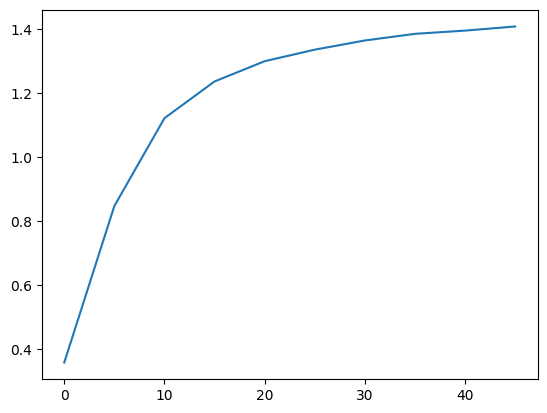

In [89]:
import time
import matplotlib.pyplot as plt
import random

list_size = 10000
list_nb = 40
ns = range(0, 50, 5)
times = [0 for _ in ns]
for i in range(list_nb):
    l = [random.randint(0, int(1e6)) for _ in range(list_size)]
    for j in range(0, len(ns)):
        l_copy = l.copy()
        t = time.monotonic()
        quicksortIS(l_copy, ns[j])
        times[j] += time.monotonic() - t

plt.plot(ns, times)

Text(0.5, 1.0, 'Comparaison du temps de tri')

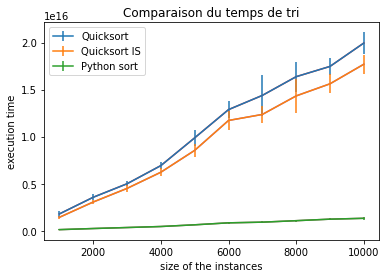

## Autre hybridation tri par insertion - quicksort

Une autre façon de procéder est d’utiliser le fait que le tri par insertion est rapide sur les tableaux
presque triés. Comme pour la variante précédente, on va stopper `quicksort` pour une taille fixée `n1`. Mais au lieu d'appeler le tri par insertion sur chacun des sous tableau, on va appeler le tri par insertion sur le tableau en entier, qui sera à ce moment presque trié.

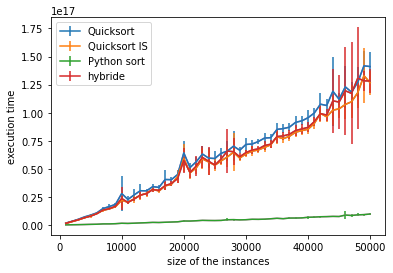

## Choix du pivot

Dans le TP précédent, on avait proposé de choisir le pivot en tirant au sort trois valeurs et en prenant la valeur médiane. Si vous ne l'avez pas fait, vous pouvez maintenant tester cette version

## Bilan 
 
Sur un même graphique, comparez les performances de quicksort, tri fusion, de la meilleure variante selon vos tests ainsi que la méthode `sort` implémentée par Python.

## Mini compétition

Proposez par groupe de TP un algorithme de tri, l'algorithme le plus rapide (exécuté sur la machine de l'enseignant et sur des tableaux générés de manière aléatoire) gagnera un petit prix pour le groupe de TP. La taille des instances sera d'au moins 10.000 entiers. Le code sera a déposer sur moodle.